# Playground V1
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [1]:
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances, adjusted_rand_score

import numpy as np

import matplotlib.pyplot as plt

In [2]:
import sys
print("Interpreter:", sys.executable)

import carve
print("carve from:", carve.__file__)

import inspect
print("Public names:", [n for n in dir(carve) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve, inspect.isclass) if o.__module__.startswith("carve")])
print("Functions:", [n for n, o in inspect.getmembers(carve, inspect.isfunction) if o.__module__.startswith("carve")])

Interpreter: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/.venv/bin/python
carve from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/__init__.py
Public names: ['CARVE', 'SpectralClusteringCARVE', 'api', 'cluster', 'config', 'grids']
Classes: ['CARVE', 'SpectralClusteringCARVE']
Functions: []


In [3]:
import carve.sim
print("carve.sim from:", carve.sim.__file__)

import inspect
print("Public names:", [n for n in dir(carve.sim) if not n.startswith("_")])
print("Classes:", [n for n, o in inspect.getmembers(carve.sim, inspect.isclass) if o.__module__.startswith("carve.sim")])
print("Functions:", [n for n, o in inspect.getmembers(carve.sim, inspect.isfunction) if o.__module__.startswith("carve.sim")])

carve.sim from: /Users/kaiwycik/Documents/GitHub/ClusteringValidation/src/carve/sim/__init__.py
Public names: ['ScDesign3Simulator', 'api', 'simulate_clusters']
Classes: ['ScDesign3Simulator']
Functions: ['simulate_clusters']


In [4]:
from carve import CARVE
from carve.config import ValidatorConfig

from carve.sim import simulate_clusters, ScDesign3Simulator

---

## 1. Playground

In [5]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


In [6]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

X.shape, y.shape

((70000, 784), (70000,))

---

### Get most stable pre-processing pipeline:

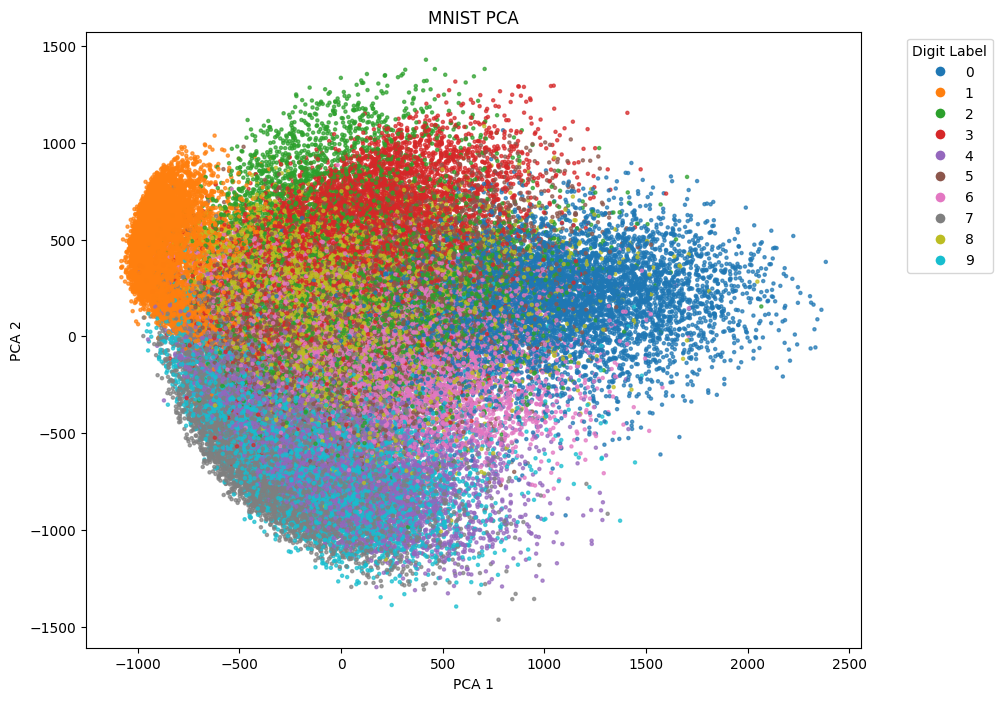

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.astype(int), cmap='tab10', s=5, alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('MNIST PCA')

handles = []
labels = np.unique(y)
for label in labels:
    handles.append(plt.Line2D([], [], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(int(label))), markersize=8, label=str(label)))
plt.legend(handles=handles, title='Digit Label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [8]:
rng = np.random.default_rng(seed=0)
idx = rng.choice(X.shape[0], size=500, replace=False)
X_sub = X[idx]
y_sub = y[idx]

In [9]:
# pairwise squared Euclidean distances
D2 = pairwise_distances(X_sub, metric='sqeuclidean')
median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
gamma = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0

In [10]:
# spectral clustering
n_clusters = len(np.unique(y))
spectral = SpectralClustering(n_clusters=n_clusters, gamma=gamma, affinity='rbf', random_state=42, n_jobs=-1)
labels_pred = spectral.fit_predict(X_sub)

# get ARI
ari = adjusted_rand_score(y_sub.astype(str), labels_pred)
print("ARI:", ari)

ARI: 0.3889420197008759


ARI of 0.3889 --> can't expect CARVE to work well on this without any pre-processing. 

In [11]:
# hierarchical clustering
n_clusters = len(np.unique(y))
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_pred = hierarchical.fit_predict(X_sub)

# get ARI
ari = adjusted_rand_score(y_sub.astype(str), labels_pred)
print("ARI:", ari)

ARI: 0.4914121605563725


In [12]:
cfg1 = ValidatorConfig(
    X=X_sub,
    ref_labels=y_sub, 
    B=100,
    model_grids=[
        (SpectralClustering, {"n_clusters": [8, 9, 10, 11, 12], 'gamma': [gamma]}),
        # (AgglomerativeClustering, {"n_clusters": [8, 9, 10, 11, 12], 'linkage': ['ward']})
    ]
)

val1 = CARVE(cfg1)
val1.validate(random_preprocess=False, random_state=42)

Grid configs:   0%|          | 0/5 [00:00<?, ?it/s]

In [13]:
val1.plot_results()

In [14]:
# val1.plot_results_preprocessing()

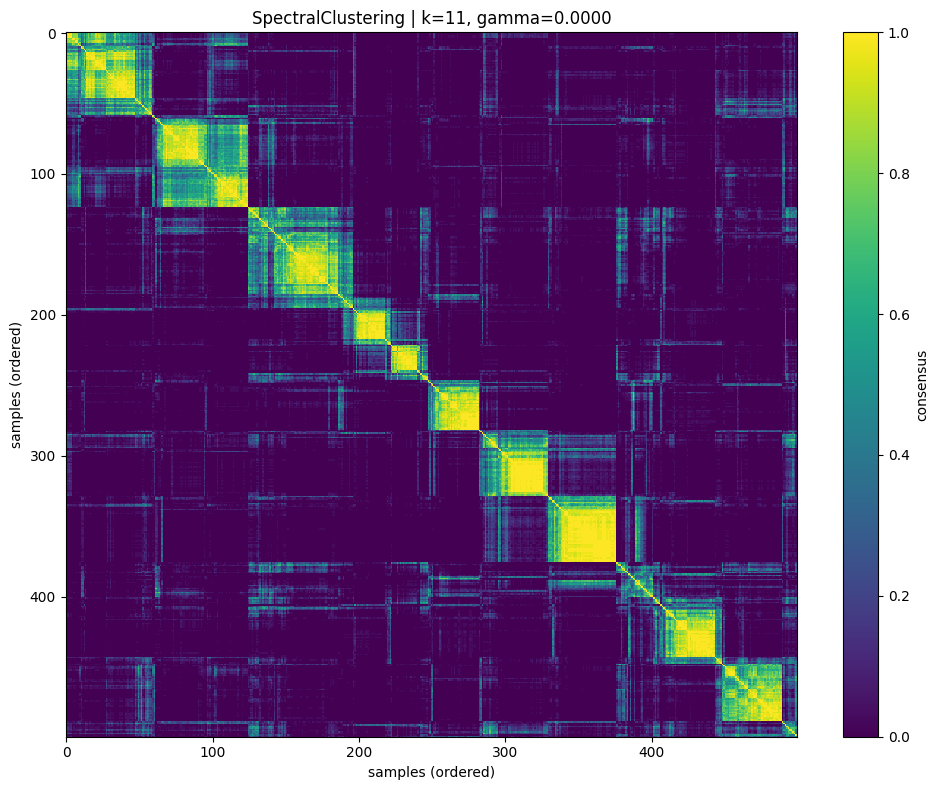

In [15]:
val1.plot_consensus_matrix()

In [17]:
val1.plot_clustering()

FigureWidget({
    'data': [{'customdata': {'bdata': ('AAAAAAAAIEAAAAAAAAAAAAAAAAAAAP' ... 'C4Q+z06D9WP/Wqpg3oP3aDKfJZN9g/'),
                             'dtype': 'f8',
                             'shape': '48, 6'},
              'hovertemplate': ('sample %{customdata[0]}<br>clu' ... 'tomdata[5]:.4f}<extra></extra>'),
              'legendgroup': 'cluster-0',
              'marker': {'color': '#636EFA',
                         'line': {'color': 'black', 'width': 1.0},
                         'opacity': 0.3,
                         'size': {'bdata': ('O8CnCQ3WIEC1lsWf79scQIruWZ4AFS' ... 'nBsdTRJkAd5xD4kKMhQK2nnTz1rCJA'),
                                  'dtype': 'f8'}},
              'mode': 'markers',
              'name': 'cluster 1',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'ddbc5b4a-d279-462e-bb95-05f0509a036d',
              'x': {'bdata': ('xIcjg1R2Y8DBV10VxiZxwODpuRCrqX' ... 'qHWP9fZ8Bh7ORmk2lgQEp0cVY0hHZA'),
                  

---

### Running on preprocessed data:

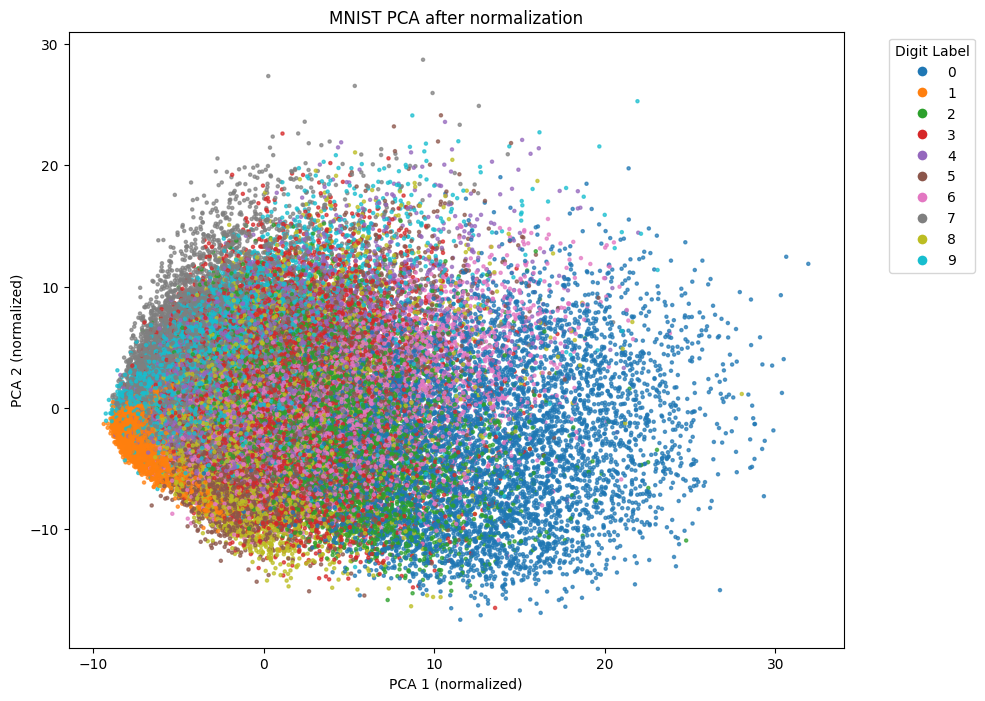

In [29]:
from sklearn.preprocessing import StandardScaler

# normalize (mean 0, std 1)
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

# PCA transform
pca = PCA(n_components=100)
X_std_pca = pca.fit_transform(X_norm)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_std_pca[:, 0], X_std_pca[:, 1], c=y.astype(int), cmap='tab10', s=5, alpha=0.7)
plt.xlabel('PCA 1 (normalized)')
plt.ylabel('PCA 2 (normalized)')
plt.title('MNIST PCA after normalization')

handles = []
labels = np.unique(y)
for label in labels:
    handles.append(plt.Line2D([], [], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(int(label))), markersize=8, label=str(label)))
plt.legend(handles=handles, title='Digit Label', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [30]:
X_std_pca.shape

(70000, 100)

In [31]:
rng = np.random.default_rng(seed=0)
idx = rng.choice(X.shape[0], size=500, replace=False)
X_std_pca_sub = X_std_pca[idx]
y_std_pca_sub = y[idx]

In [32]:
# pairwise squared Euclidean distances
D2 = pairwise_distances(X_std_pca_sub, metric='sqeuclidean')
median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
gamma = 1.0 / (2.0 * median_d2) if median_d2 > 0 else 1.0

In [33]:
# spectral clustering
n_clusters = len(np.unique(y))
spectral = SpectralClustering(n_clusters=n_clusters, gamma=gamma, affinity='rbf', random_state=42, n_jobs=-1)
labels_log1p_pred = spectral.fit_predict(X_std_pca_sub)

# get ARI
ari = adjusted_rand_score(y_std_pca_sub.astype(str), labels_log1p_pred)
print("ARI:", ari)

ARI: 0.3619784722171592


In [34]:
# hierarchical clustering
n_clusters = len(np.unique(y))
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_log1p_pred = hierarchical.fit_predict(X_std_pca_sub)

# get ARI
ari = adjusted_rand_score(y_std_pca_sub.astype(str), labels_log1p_pred)
print("ARI:", ari)

ARI: 0.3660145083911082


In [36]:
cfg2 = ValidatorConfig(
    X=X_std_pca_sub,
    ref_labels=y_std_pca_sub, 
    B=100,
    # K=[8, 9, 10, 11, 12],
    # model_grids=[(SpectralClustering, {"n_clusters": [8, 9, 10, 11, 12], 'gamma': [gamma]})],
    model_grids=[(AgglomerativeClustering, {"n_clusters": [8, 9, 10, 11, 12], 'linkage': ['ward']})]
)

val2 = CARVE(cfg2)
val2.validate(random_preprocess=True, random_state=42)

Grid configs:   0%|          | 0/5 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


ValueError: Input X contains NaN.
AgglomerativeClustering does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

ValueError: keyword grid_alpqha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_rasterized', 'grid_sketch_params', 'grid_snap', 'grid_solid

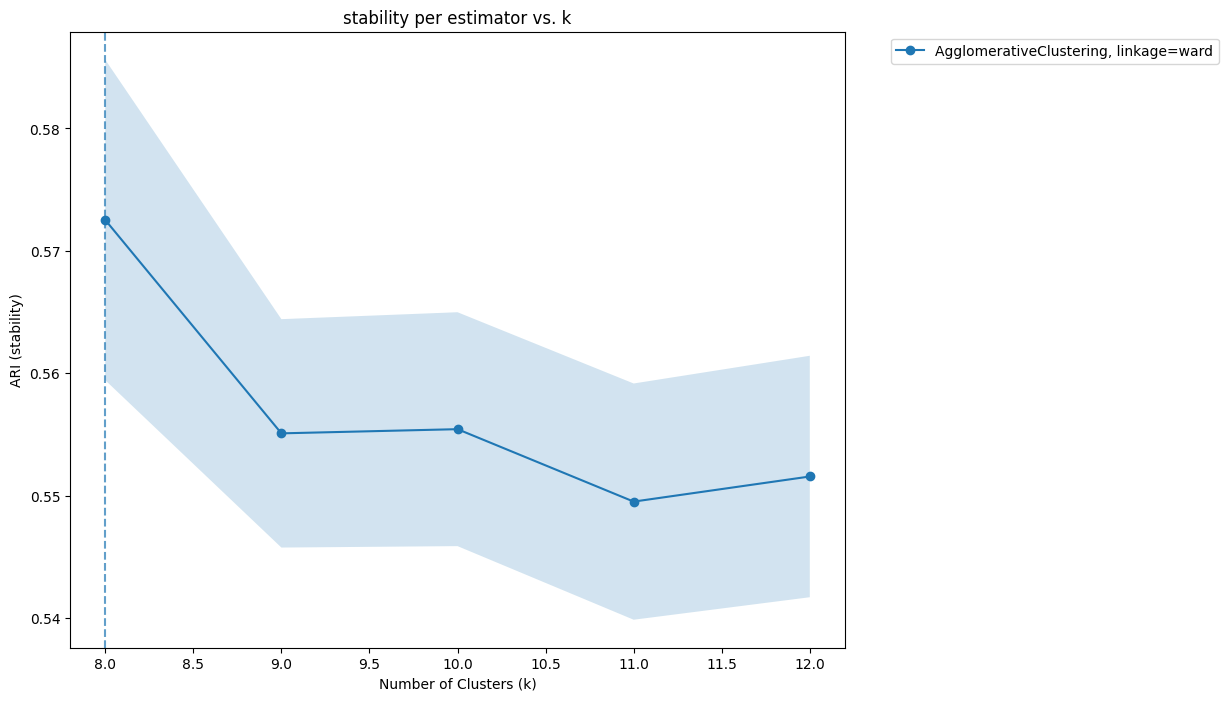

In [ ]:
val2.plot_global()